In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float 
    summary: str

In [3]:
graph = StateGraph(BatsmanState)

Add Nodes


In [4]:
def calculate_strike_rate(state: BatsmanState):
    strike_rate = (state['runs'] / state['balls']) * 100
    return {"strike_rate": strike_rate}

In [5]:
def calculate_balls_per_boundary(state: BatsmanState):
    balls_per_boundary = state['balls'] / (state['fours'] + state['sixes'])
    return {"balls_per_boundary": balls_per_boundary}

In [6]:
def calculate_boundary_percent(state: BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {"boundary_percent": boundary_percent}

In [7]:
def summary(state: BatsmanState):
    summary = f"""
    Strike rate - {state['strike_rate']} \n
    Balls per boundary - {state['balls_per_boundary']} \n
    Boundary percent - {state['boundary_percent']}    
    """
    return {"summary": summary}

In [8]:
graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

In [9]:
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_strike_rate', "summary")
graph.add_edge('calculate_balls_per_boundary', "summary")
graph.add_edge('calculate_boundary_percent', "summary")

graph.add_edge("summary", END)

In [10]:
workflow = graph.compile()

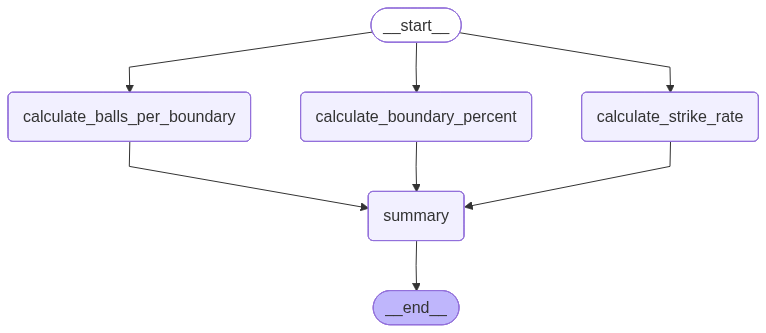

In [11]:
workflow

In [12]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4,
}

# final_state = workflow.invoke(initial_state)
final_state = workflow.invoke(initial_state, stream_mode="debug")
final_state

[{'step': 1,
  'timestamp': '2025-11-08T10:18:49.873888+00:00',
  'type': 'task',
  'payload': {'id': '5e552fbb-ef91-d274-b49a-3bd4434dc769',
   'name': 'calculate_balls_per_boundary',
   'input': {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4},
   'triggers': ('branch:to:calculate_balls_per_boundary',)}},
 {'step': 1,
  'timestamp': '2025-11-08T10:18:49.873916+00:00',
  'type': 'task',
  'payload': {'id': 'ae67d652-7bc9-5e59-2289-51d116dd894d',
   'name': 'calculate_boundary_percent',
   'input': {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4},
   'triggers': ('branch:to:calculate_boundary_percent',)}},
 {'step': 1,
  'timestamp': '2025-11-08T10:18:49.873923+00:00',
  'type': 'task',
  'payload': {'id': '77a423fb-1f7b-e7fd-2577-94fd4ac5b275',
   'name': 'calculate_strike_rate',
   'input': {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4},
   'triggers': ('branch:to:calculate_strike_rate',)}},
 {'step': 1,
  'timestamp': '2025-11-08T10:18:49.915902+00:00',
  'type': 'task_resul